# PR3 · Risk Parity and Hierarchical Risk Parity

A portfolio that looks balanced in dollars can be very unbalanced in risk. Risk parity gives every asset an equal share of the *risk*, without forecasting returns. Hierarchical Risk Parity (HRP) goes one step further: it first works out which assets behave alike, then balances risk between those groups.

## 1. Motivation

The classic "balanced" portfolio puts 60% in stocks and 40% in bonds. It sounds diversified. But stocks are several times more volatile than medium-term bonds, so when the portfolio has a bad month, the stock part is almost always the reason. In risk terms, 60/40 is close to 100/0.

Simple risk parity fixes that for a handful of assets. With a bigger universe, a new problem appears. Suppose you hold eight equity funds and one gold fund. Equal risk *per fund* still means eight parts equity risk to one part gold. Those eight funds mostly move together, so they are really one big bet counted eight times. And the classic optimiser alternative, minimum variance (PR1), needs to invert the covariance matrix, which amplifies estimation noise as the number of assets grows. HRP was designed for exactly this situation.

## 2. Intuition

**Risk parity.** Think of a tug-of-war team with one heavyweight and four children. With five people on the rope, the result still depends almost entirely on the heavyweight. A balanced team has everyone pulling equally hard. In a portfolio, each asset "pulls" on total risk according to how much you hold and how volatile and correlated it is. Risk parity sets the weights so that every asset pulls equally: less money in volatile assets, more in calm ones.

**Hierarchical Risk Parity.** Picture splitting a budget across a company. You don't hand every employee the same amount. First you split between departments, then between teams inside each department, then between people. HRP does the same with risk:

1. **Build a family tree** of the assets from their correlations: the two Treasury funds are siblings, the equity funds form a big family, gold sits on its own branch.
2. **Order the assets** along the tree, so that similar assets sit next to each other.
3. **Split the money top-down.** Divide the list into two halves, and give each half money in inverse proportion to its risk. Then repeat inside each half, all the way down to single assets.

Because money is split between groups first, a crowd of similar assets can't take over the portfolio. And HRP never inverts the covariance matrix, so it doesn't amplify noise the way minimum variance does.

## 3. The math

### 3.1 Risk contributions

Portfolio volatility is $\sigma_p = \sqrt{w^\top\Sigma w}$. Its sensitivity to $w_i$ is $\partial\sigma_p/\partial w_i = (\Sigma w)_i/\sigma_p$. The **risk contribution** of asset $i$ is its weight times that sensitivity:
$$
RC_i = w_i \,\frac{(\Sigma w)_i}{\sigma_p}, \qquad \sum_i RC_i = \frac{w^\top \Sigma w}{\sigma_p} = \sigma_p .
$$
So $RC_i/\sigma_p$ is the share of total risk coming from asset $i$.

### 3.2 Two versions of risk parity

1. **Inverse volatility:** $w_i \propto 1/\sigma_i$. Exactly balanced if all correlations are equal.
2. **Equal risk contribution (ERC):** long-only weights with $RC_i = \sigma_p/N$ for all $i$, found numerically by minimising $\sum_i (RC_i - \sigma_p/N)^2$ subject to $w_i \ge 0$, $\sum_i w_i = 1$.

### 3.3 Hierarchical Risk Parity (López de Prado, 2016)

**Step 1: tree clustering.** Turn correlations into distances, so that perfectly correlated assets are at distance 0 and perfectly opposite ones at distance 1:
$$
d_{ij} = \sqrt{\tfrac{1}{2}\,(1 - \rho_{ij})}.
$$
Then **hierarchical clustering** repeatedly merges the two closest assets or groups into a new group, until everything is in one tree. The result is drawn as a **dendrogram**.

**Step 2: quasi-diagonalisation.** Reorder the assets in the order of the tree's leaves. Similar assets end up next to each other, and large correlations gather near the diagonal of the reordered matrix.

**Step 3: recursive bisection.** Start with all assets in one list with weight 1. Split the list into two halves $L$ and $R$. For each half, compute the variance of its own inverse-variance portfolio:
$$
V_L = \tilde w_L^\top \Sigma_L \tilde w_L, \qquad \tilde w_L \propto \frac{1}{\operatorname{diag}(\Sigma_L)} .
$$
Give the left half the share $\alpha = 1 - \dfrac{V_L}{V_L + V_R}$ of the current weight, and the right half $1-\alpha$. The riskier half gets less. Repeat inside each half until every list has one asset.

Every step uses only variances and covariances of sub-groups. No matrix is inverted, and no expected returns are needed.

## 4. Code it

### 4.1 Setup: 14 ETFs across asset classes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import squareform
from matplotlib.colors import LinearSegmentedColormap

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.width", 140)
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])

assets = ["SPY", "IWM", "XLK", "XLF", "XLE", "XLV", "XLP", "XLU",   # US equity: market, small caps, 6 sectors
          "TLT", "IEF",                                              # Treasuries
          "LQD", "HYG",                                              # corporate credit
          "GLD", "VNQ"]                                              # gold, real estate
asset_class = pd.Series({**{a: "Equity" for a in assets[:8]}, "TLT": "Treasuries", "IEF": "Treasuries",
                         "LQD": "Credit", "HYG": "Credit", "GLD": "Real assets", "VNQ": "Real assets"})
returns = prices[assets].pct_change().dropna()
Sigma = returns.cov() * 252
corr = returns.corr()

### 4.2 Risk contributions of a 60/40 portfolio

In [2]:
def risk_contributions(w, Sigma):
    w = np.asarray(w)
    sigma_p = np.sqrt(w @ Sigma @ w)
    return w * (Sigma @ w) / sigma_p             # RC_i = w_i (Sigma w)_i / sigma_p

w_6040 = pd.Series(0.0, index=assets)
w_6040[["SPY", "IEF"]] = [0.6, 0.4]
rc = pd.Series(risk_contributions(w_6040, Sigma.values), index=assets)
print(f"Portfolio volatility: {np.sqrt(w_6040 @ Sigma @ w_6040):.1%}  (sum of RC_i = {rc.sum():.1%})")
print(f"Share of risk from SPY: {rc['SPY'] / rc.sum():.0%},  from IEF: {rc['IEF'] / rc.sum():.0%}")

Portfolio volatility: 9.9%  (sum of RC_i = 9.9%)
Share of risk from SPY: 100%,  from IEF: 0%


A 60/40 portfolio has 40% of its *money* in bonds, but essentially 100% of its *risk* comes from stocks. Two things cause this. Stocks are about three times as volatile as IEF. And over this period IEF was slightly negatively correlated with stocks, so its contribution to risk is close to zero. For a risk manager, 60/40 is a stock portfolio with a cushion.

### 4.3 Inverse volatility and ERC

In [3]:
def inverse_vol_weights(Sigma):
    inv = 1 / np.sqrt(np.diag(Sigma))           # w_i proportional to 1 / sigma_i
    return pd.Series(inv / inv.sum(), index=Sigma.index)

def erc_weights(Sigma):
    S, n = Sigma.values, len(Sigma)
    def objective(w):
        rc = risk_contributions(w, S)
        return ((rc - rc.sum() / n) ** 2).sum() * 1e4         # squared gaps from sigma_p / N
    res = minimize(objective, x0=inverse_vol_weights(Sigma).values, method="SLSQP",
                   bounds=[(0, 1)] * n, constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return pd.Series(res.x, index=Sigma.index)

def class_view(w):
    """Money share and risk share, summed by asset class."""
    rc = pd.Series(risk_contributions(w, Sigma.values), index=assets)
    return pd.DataFrame({"money": w.groupby(asset_class).sum(),
                         "risk": (rc / rc.sum()).groupby(asset_class).sum()})

portfolios = {"60/40": w_6040,
              "Equal weight": pd.Series(1 / len(assets), index=assets),
              "Inverse vol": inverse_vol_weights(Sigma),
              "ERC": erc_weights(Sigma)}
pct = lambda x: f"{round(x, 2) + 0:.0%}"
pd.concat({name: class_view(w) for name, w in portfolios.items()}, axis=1).map(pct)

60/40       Equal weight      Inverse vol        ERC     
            money  risk        money risk       money risk money risk
Credit         0%    0%          14%   6%         25%  16%   19%  14%
Equity        60%  100%          57%  81%         42%  69%   35%  57%
Real assets    0%    0%          14%  14%         11%  13%   12%  14%
Treasuries    40%    0%          14%  -1%         22%   3%   35%  14%

Summed by asset class:

- **Equal weight** puts 57% of the money in equities, but equities supply 81% of the risk.
- **Inverse volatility** moves money towards bonds, but equities still supply 69% of the risk. It ignores correlations, and the eight equity funds are highly correlated with each other.
- **ERC** balances risk *per fund* exactly, so each of the 14 funds supplies 1/14 of the risk. But eight of them are equity funds, so equities still end up with 8/14 ≈ 57% of the risk. This is the "crowd" problem from the Motivation: balancing per asset doesn't balance per *kind* of asset.

### 4.4 HRP step by step

**Step 1: the tree.** We compute the distances $d_{ij}$ and let scipy build the tree with *single linkage*: the distance between two groups is the distance between their two closest members.

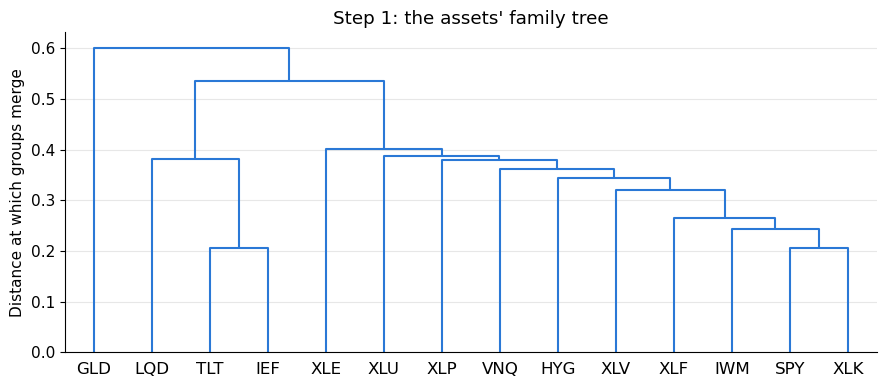

In [4]:
dist = np.sqrt(0.5 * (1 - corr))                                     # d_ij = sqrt((1 - rho_ij) / 2)
link = linkage(squareform(dist.values, checks=False), method="single")

fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(link, labels=assets, ax=ax, color_threshold=0, above_threshold_color=COLORS[0])
ax.set_ylabel("Distance at which groups merge")
ax.set_title("Step 1: the assets' family tree")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

The tree recovers the economic structure from returns alone, with no labels given:

- **Treasuries** (TLT, IEF) merge first, at the smallest distance, and then join investment-grade credit (LQD).
- **Equities** form one big family: SPY and XLK are nearly identical, then small caps, financials, and the other sectors join one by one.
- **High-yield bonds (HYG) and real estate (VNQ) sit inside the equity family.** By their behaviour they are equity-like risks, whatever their label says.
- **Gold** joins last. It is the most independent asset in the universe.

After reordering, the correlation matrix shows clear blocks along the diagonal: a small bond block and a large equity block.

**Step 2: reorder the assets** along the tree's leaves. The correlation matrix becomes "quasi-diagonal": similar assets sit next to each other.

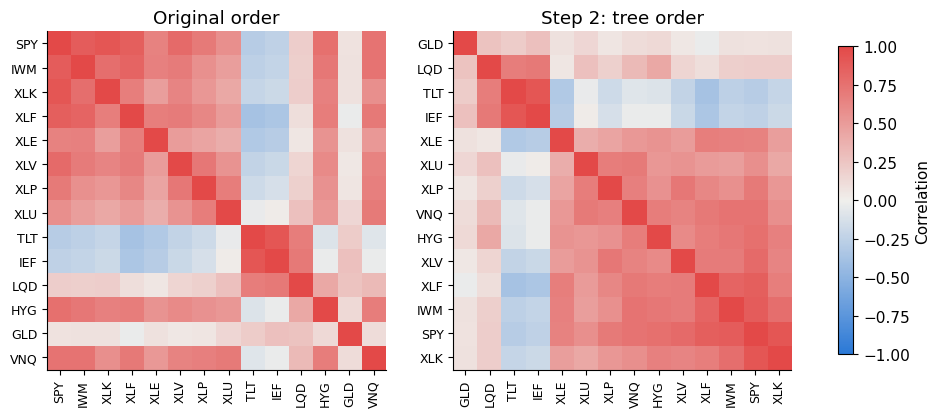

In [5]:
order = [assets[i] for i in leaves_list(link)]          # leaf order of the tree

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cols, title in [(axes[0], assets, "Original order"), (axes[1], order, "Step 2: tree order")]:
    im = ax.imshow(corr.loc[cols, cols], cmap=DIVERGING, vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)), cols, rotation=90, fontsize=9)
    ax.set_yticks(range(len(cols)), cols, fontsize=9)
    ax.set_title(title)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="Correlation")
plt.show()

**Step 3: recursive bisection.** The function follows Section 3.3 line by line.

In [6]:
def cluster_variance(Sigma, members):
    """Variance of the inverse-variance portfolio of a group: V = w' Sigma w."""
    S = Sigma.loc[members, members].values
    w = 1 / np.diag(S)
    w = w / w.sum()
    return w @ S @ w

def hrp_weights(Sigma, corr):
    dist = np.sqrt(0.5 * (1 - corr))
    link = linkage(squareform(dist.values, checks=False), method="single")     # step 1
    order = [corr.index[i] for i in leaves_list(link)]                          # step 2
    w = pd.Series(1.0, index=order)
    groups = [order]
    while groups:                                                               # step 3
        next_groups = []
        for g in groups:
            if len(g) < 2:
                continue
            left, right = g[: len(g) // 2], g[len(g) // 2:]                      # split the list in two halves
            v_left, v_right = cluster_variance(Sigma, left), cluster_variance(Sigma, right)
            alpha = 1 - v_left / (v_left + v_right)                              # riskier half gets less
            w[left] *= alpha
            w[right] *= 1 - alpha
            next_groups += [left, right]
        groups = next_groups
    return w.reindex(Sigma.index)

portfolios["HRP"] = hrp_weights(Sigma, corr)
w_table = pd.DataFrame(portfolios).drop(columns="60/40")
w_table.map(pct)

,Equal weight,Inverse vol,ERC,HRP
SPY,7%,6%,4%,2%
IWM,7%,4%,3%,1%
XLK,7%,5%,4%,1%
XLF,7%,5%,4%,1%
XLE,7%,4%,4%,2%
XLV,7%,6%,5%,3%
XLP,7%,7%,6%,5%
XLU,7%,6%,5%,3%
TLT,7%,7%,12%,4%
IEF,7%,15%,23%,42%


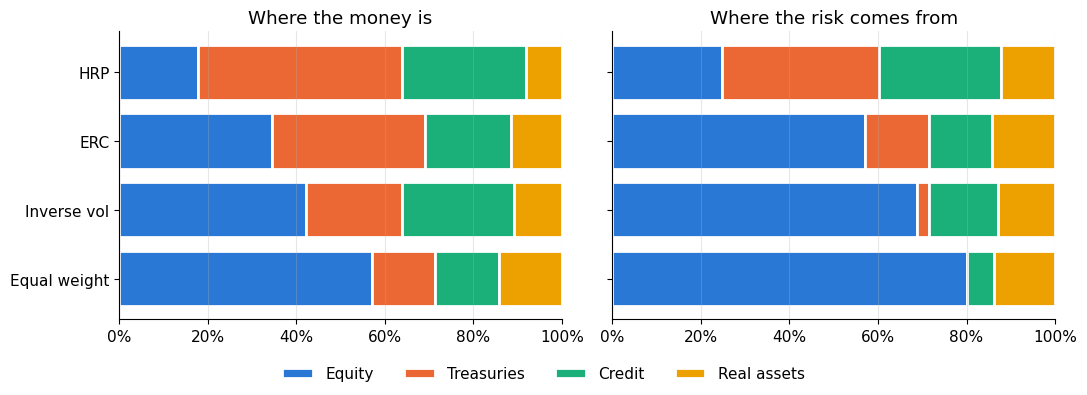

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
names = ["Equal weight", "Inverse vol", "ERC", "HRP"]
classes = ["Equity", "Treasuries", "Credit", "Real assets"]
for ax, kind, title in [(axes[0], "money", "Where the money is"), (axes[1], "risk", "Where the risk comes from")]:
    left = np.zeros(len(names))
    for k, cls in enumerate(classes):
        vals = np.array([class_view(portfolios[n]).loc[cls, kind] for n in names])
        ax.barh(names, vals, left=left, color=COLORS[k], edgecolor="white", linewidth=2, label=cls)
        left += vals
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.grid(axis="y", visible=False)
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, ncol=4, loc="lower center")
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

HRP looks very different from the others. Because the first split separates gold, bonds and investment-grade credit from the large equity-like family, the equity block as a whole receives a modest share. Each equity fund then gets only 1–5%. The result is the most balanced risk split *across asset classes*: no class supplies more than about a third of the risk. Equity's share falls from 57% under ERC to about a quarter.

The flip side: HRP puts 42% of its money in IEF alone. Within the bond half of the tree, IEF is the calmest asset, and the inverse-variance split favours it strongly. HRP is balanced across groups, but can be concentrated within them.

### 4.5 Out-of-sample backtest

Every month, each method estimates its weights from the past year of data and holds them for the next month. We add minimum variance (GMV, from PR1, which allows short positions) to compare HRP with the classic optimiser.

In [8]:
def gmv_weights(Sigma):
    x = np.linalg.solve(Sigma.values, np.ones(len(Sigma)))     # Sigma^{-1} 1
    return pd.Series(x / x.sum(), index=Sigma.index)

methods = {
    "60/40": lambda S, C: w_6040,
    "Equal weight": lambda S, C: pd.Series(1 / len(assets), index=assets),
    "Inverse vol": lambda S, C: inverse_vol_weights(S),
    "ERC": lambda S, C: erc_weights(S),
    "HRP": lambda S, C: hrp_weights(S, C),
    "GMV": lambda S, C: gmv_weights(S),
}
month_ends = returns.groupby(returns.index.to_period("M")).tail(1).index
oos = {m: [] for m in methods}
turnover = {m: [] for m in methods}
previous = {m: None for m in methods}

for i, date in enumerate(month_ends[:-1]):
    past = returns.loc[:date].tail(252)
    if len(past) < 252:
        continue
    S, C = past.cov() * 252, past.corr()
    nxt = returns.loc[date:month_ends[i + 1]].iloc[1:]           # next month, out of sample
    for m, f in methods.items():
        w = f(S, C)
        oos[m].append(nxt @ w)
        if previous[m] is not None:
            turnover[m].append((w - previous[m]).abs().sum())     # how much the weights changed
        previous[m] = w

oos = pd.DataFrame({m: pd.concat(v) for m, v in oos.items()})
rf = (prices["^IRX"].ffill() / 100 / 252).shift(1).reindex(oos.index)
excess = oos.sub(rf, axis=0)
value = (1 + oos).cumprod()
perf = pd.DataFrame({
    "CAGR": value.iloc[-1] ** (252 / len(oos)) - 1,
    "Volatility": oos.std() * np.sqrt(252),
    "Sharpe": np.sqrt(252) * excess.mean() / excess.std(),
    "Max drawdown": (value / value.cummax() - 1).min(),
    "Monthly turnover": pd.Series({m: np.mean(t) for m, t in turnover.items()}),
})
fmt = {"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.1%}", "Monthly turnover": "{:.0%}"}
perf.apply(lambda col: col.map(fmt[col.name].format))

,CAGR,Volatility,Sharpe,Max drawdown,Monthly turnover
60/40,9.5%,10.0%,0.81,-21.0%,0%
Equal weight,9.6%,11.0%,0.74,-26.5%,0%
Inverse vol,7.6%,8.6%,0.71,-21.3%,3%
ERC,6.8%,7.4%,0.71,-17.0%,5%
HRP,4.9%,6.5%,0.53,-18.4%,14%
GMV,2.2%,3.8%,0.18,-14.8%,26%


- **The methods line up in order of risk.** Equal weight → inverse vol → ERC → HRP → GMV each has lower volatility than the one before. HRP (6.5%) sits between the risk-parity methods and minimum variance.
- **HRP is much more stable than GMV.** It needs about half the monthly turnover (14% vs 26%) and never holds short positions, while delivering a far better Sharpe ratio (0.53 vs 0.18). That is HRP's main selling point: most of the risk reduction of an optimiser, without inverting a noisy covariance matrix.
- **But in this period, lower risk meant lower risk-adjusted return.** 60/40 and equal weight had the best Sharpe ratios, because 2011–2026 strongly rewarded equity risk, and HRP's large position in Treasuries was hit by the 2022 rate shock.
- **HRP trades more than inverse vol and ERC.** Its tree can change shape from month to month, which reshuffles the top-level splits.

The fair conclusion: HRP is an excellent *risk* engine, robust and diversified across asset classes. Whether that pays off depends on the period. Its strength shows most when equity-heavy portfolios struggle and the other asset classes really diversify.

## 5. Takeaways and where it breaks

- **Money weights are not risk weights.** Always look at risk contributions. A "diversified" portfolio can be one big bet.
- **Risk parity needs no return forecasts**, only the covariance matrix, which is the input we can estimate well (PR1, PR2).
- **HRP balances risk between groups, not just assets.** It is robust because it never inverts $\Sigma$, it is long-only by construction, and it stays stable as the universe grows.
- **HRP has its own arbitrary choices:** the linkage method (single, complete, average, Ward) and splitting the ordered list in halves rather than along the tree's actual branches. Different choices can give noticeably different weights. Test them out-of-sample, not in-sample.
- **Low risk is not the same as high return.** Risk-based portfolios hold a lot of bonds. Funds that run them often use leverage to reach a target volatility, which adds borrowing costs and hurts when stocks and bonds fall together, as in 2022.

**What you could build:** an allocation engine for the club that produces inverse-vol, ERC and HRP weights for any list of assets each month, with a dendrogram and a risk-contribution report, so the team can see *why* each portfolio looks the way it does.